#NLP-Based News Category Classification Using TF-IDF and Multinomial Naive Bayes

## 1. Check the Dataset

The BBC News dataset is stored in the `bbc` folder. In this step, we check the dataset path and display the available news categories to make sure the dataset has been loaded correctly.

In [3]:
import os
import zipfile
zip_path = '/content/bbc-fulltext.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')
dataset_path = '/content/bbc'
print("Categories in the dataset:")
print(os.listdir(dataset_path))

Categories in the dataset:
['business', 'politics', 'sport', 'entertainment', 'README.TXT', 'tech']


## 2. Load the Dataset into a DataFrame

The news articles are read from each category folder and stored in a Pandas DataFrame. Each article is stored with its corresponding category label. The total number of articles and categories are displayed to verify that the dataset was loaded correctly.

In [4]:
import pandas as pd
import os
data = []
for category in ['tech', 'entertainment', 'politics', 'business', 'sport']:
    category_path = os.path.join(dataset_path, category)
    for filename in os.listdir(category_path):
        file_path = os.path.join(category_path, filename)
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        data.append({
            'text': text,
            'category': category
        })
df = pd.DataFrame(data)
print("Dataset loaded successfully!")
print("Number of articles:", len(df))
print("Number of categories:", df['category'].nunique())

Dataset loaded successfully!
Number of articles: 2225
Number of categories: 5


## 3. View the Dataset

The `head()` function is used to display the first few rows of the dataset. This helps us check the structure of the DataFrame and view the news articles along with their category labels.

In [5]:
df.head()

,text,category
0,"Rich pickings for hi-tech thieves\n\nViruses, ...",tech
1,China net cafe culture crackdown\n\nChinese au...,tech
2,The pirates with no profit motive\n\nTwo men w...,tech
3,US state acts to stop 'spammers'\n\nUS state T...,tech
4,T-Mobile bets on 'pocket office'\n\nT-Mobile h...,tech


## 4. Check the Category Distribution

The `value_counts()` function is used to count the number of news articles in each category. This helps us understand how the articles are distributed among the five news categories.

In [6]:
df['category'].value_counts()

,count
category,
sport,511
business,510
politics,417
tech,401
entertainment,386


## 5. View a Sample News Article

The first news article is displayed to examine the raw text before applying any preprocessing. This helps us understand the original format and content of the news articles.

In [7]:
print(df.iloc[0]['text'])

Rich pickings for hi-tech thieves

Viruses, trojans and other malicious programs sent on to the net to catch you out are undergoing a subtle change.

The shift is happening as tech savvy criminals turn to technology to help them con people out of cash, steal valuable data or take over home PCs. Viruses written to make headlines by infecting millions are getting rarer. Instead programs are now crafted for directly criminal ends and firms are tightening up networks with defences to combat the new wave of malicious code.

The growing criminal use of malware has meant the end of the neat categorisation of different sorts of viruses and malicious programs. Before now it has been broadly possible to name and categorise viruses by the method they use to spread and how they infect machines. But many of the viruses written by criminals roll lots of technical tricks together into one nasty package.

"You cannot put them in to the neat little box that you used to," said Pete Simpson, head of the 

## 6. Text Preprocessing

The text is cleaned before applying the machine learning model. In this step, the articles are converted to lowercase, punctuation and numbers are removed, and common English stopwords are removed. A preprocessing function is created to perform these operations on the news articles.

In [8]:
import nltk
nltk.download('stopwords')
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Split text into words
    words = text.split()
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    # Join the words back into a single string
    return ' '.join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 7. Test the Text Preprocessing

The preprocessing function is tested on the first news article. The original and cleaned versions of the article are displayed to compare the changes made during preprocessing.

In [9]:
original_text = df.iloc[0]['text']
cleaned_text = preprocess_text(original_text)
print("ORIGINAL TEXT:\n")
print(original_text[:1000])
print("\n\nCLEANED TEXT:\n")
print(cleaned_text[:1000])

ORIGINAL TEXT:

Rich pickings for hi-tech thieves

Viruses, trojans and other malicious programs sent on to the net to catch you out are undergoing a subtle change.

The shift is happening as tech savvy criminals turn to technology to help them con people out of cash, steal valuable data or take over home PCs. Viruses written to make headlines by infecting millions are getting rarer. Instead programs are now crafted for directly criminal ends and firms are tightening up networks with defences to combat the new wave of malicious code.

The growing criminal use of malware has meant the end of the neat categorisation of different sorts of viruses and malicious programs. Before now it has been broadly possible to name and categorise viruses by the method they use to spread and how they infect machines. But many of the viruses written by criminals roll lots of technical tricks together into one nasty package.

"You cannot put them in to the neat little box that you used to," said Pete Simps

## 8. Apply Preprocessing to the Dataset

The preprocessing function is applied to all news articles in the dataset. A new `cleaned_text` column is created to store the processed articles along with their original text and category.

In [10]:
df['cleaned_text'] = df['text'].apply(preprocess_text)
print("Preprocessing completed!")
print(df[['text', 'cleaned_text', 'category']].head())

Preprocessing completed!
                                                text  \
0  Rich pickings for hi-tech thieves\n\nViruses, ...   
1  China net cafe culture crackdown\n\nChinese au...   
2  The pirates with no profit motive\n\nTwo men w...   
3  US state acts to stop 'spammers'\n\nUS state T...   
4  T-Mobile bets on 'pocket office'\n\nT-Mobile h...   

                                        cleaned_text category  
0  rich pickings hitech thieves viruses trojans m...     tech  
1  china net cafe culture crackdown chinese autho...     tech  
2  pirates profit motive two men part huge networ...     tech  
3  us state acts stop spammers us state texas fil...     tech  
4  tmobile bets pocket office tmobile launched la...     tech  


## 9. Verify the Preprocessed Data

The dataset is checked after preprocessing to make sure that all articles have been processed successfully. The code checks the total number of articles, missing values, and empty cleaned text entries.

In [11]:
print("Total articles:", len(df))
print("Missing cleaned text:", df['cleaned_text'].isna().sum())
print("Empty cleaned text:", (df['cleaned_text'].str.strip() == '').sum())

Total articles: 2225
Missing cleaned text: 0
Empty cleaned text: 0


## 10. Split the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets using an 80:20 ratio. The training data is used to train the model, while the testing data is used to evaluate its performance. Stratified splitting is used to maintain a similar distribution of all five categories in both sets.

In [12]:
from sklearn.model_selection import train_test_split
X = df['cleaned_text']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training articles:", len(X_train))
print("Testing articles:", len(X_test))

Training articles: 1780
Testing articles: 445


## 11. Convert Text into TF-IDF Features

TF-IDF is used to convert the cleaned news articles into numerical features that can be understood by the machine learning model. The vectorizer is fitted only on the training data and then used to transform both the training and testing data. A maximum of 5,000 features is used to keep the feature set manageable.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1780, 5000)
Testing TF-IDF shape: (445, 5000)


## 12. Train the Naive Bayes Classifier

The Multinomial Naive Bayes algorithm is used to train the news classification model. The model learns the relationship between the TF-IDF features and their corresponding news categories using the training data.

In [14]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
print("Model training completed!")

Model training completed!


## 13. Make Predictions on the Test Data

The trained model is used to predict the categories of the test articles. The predicted categories are stored in `y_pred` and the total number of predictions is displayed.

In [15]:
y_pred = model.predict(X_test_tfidf)
print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 445


## 14. Compare Actual and Predicted Categories

The actual categories of the first 10 test articles are compared with the categories predicted by the trained model. This provides a quick check of how the model is performing before evaluating it on the complete test dataset.

In [16]:
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print("Actual:", actual, "| Predicted:", predicted)

Actual: business | Predicted: business
Actual: business | Predicted: business
Actual: entertainment | Predicted: entertainment
Actual: business | Predicted: business
Actual: business | Predicted: business
Actual: sport | Predicted: sport
Actual: politics | Predicted: politics
Actual: politics | Predicted: politics
Actual: sport | Predicted: sport
Actual: politics | Predicted: politics


## 15. Evaluate the Classification Model

The classification report is used to evaluate the performance of the model on the test data. It shows the precision, recall, and F1-score for each news category, along with the overall accuracy of the model.

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.99      0.94      0.96       102
entertainment       0.97      0.94      0.95        77
     politics       0.93      0.99      0.96        84
        sport       0.98      1.00      0.99       102
         tech       0.95      0.96      0.96        80

     accuracy                           0.97       445
    macro avg       0.97      0.97      0.96       445
 weighted avg       0.97      0.97      0.97       445



## 16. Calculate Model Accuracy

Accuracy is calculated to measure the overall performance of the classification model. It represents the percentage of news articles that were correctly classified by the model out of the total test articles.

In [18]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.9662921348314607
Accuracy percentage: 96.63 %


## 17. Display the Confusion Matrix

A confusion matrix is used to show the actual and predicted categories of the test articles. The heatmap provides a visual representation of the correct and incorrect predictions made by the model for each news category.

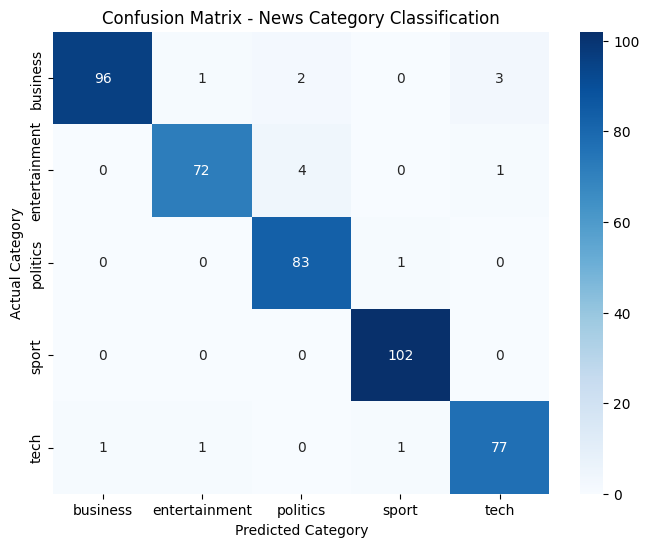

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix - News Category Classification")
plt.show()

#project

## 18. Predict the Category of a New Article

A prediction function is created to classify a new news article. The new text is first preprocessed and converted into TF-IDF features, and then the trained model predicts its news category.

In [20]:
def predict_category(news_text):
    # Preprocess the new article
    cleaned_text = preprocess_text(news_text)
    # Convert the cleaned text into TF-IDF features
    text_tfidf = tfidf.transform([cleaned_text])
    # Predict the category
    prediction = model.predict(text_tfidf)
    return prediction[0]

##19.Test with a new article

In [22]:
news = """
The football team secured a dramatic victory in the final match.
The players scored two goals in the second half and the coach praised
the team's excellent performance.
"""
result = predict_category(news)
print("Predicted Category:", result)

Predicted Category: sport


##20.Test with multiple categories

In [23]:
business_news = """
The company reported strong financial results after its sales increased
during the latest quarter. The management expects revenue to continue
growing this year.
"""
print("Predicted Category:", predict_category(business_news))

Predicted Category: business


In [24]:
tech_news = """
The technology company has launched a new smartphone with an advanced
processor, improved camera and artificial intelligence features.
"""
print("Predicted Category:", predict_category(tech_news))

Predicted Category: tech


In [25]:
politics_news = """
The government announced a new policy after discussions between
ministers and members of parliament. The proposal will be debated
during the next parliamentary session.
"""
print("Predicted Category:", predict_category(politics_news))

Predicted Category: politics


In [27]:
entertainment_news = """
The new film has received positive reviews from audiences and critics.
The actors attended the premiere and discussed the movie with fans.
"""
print("Predicted Category:", predict_category(entertainment_news))

Predicted Category: entertainment


## 21.Interactive News Category Prediction

This section provides an interactive input box where a user can enter or paste a news article.  
The trained model processes the text and predicts its news category when the **Predict Category** button is clicked.

In [29]:
import ipywidgets as widgets
from IPython.display import display, clear_output
# Create a text box for entering news
news_input = widgets.Textarea(
    value='',
    placeholder='Enter or paste a news article here...',
    description='News:',
    layout=widgets.Layout(width='80%', height='150px')
)
# Create a prediction button
predict_button = widgets.Button(
    description='Predict Category',
    button_style='success'
)
# Create an output area
output = widgets.Output()
# Function to handle button click
def on_predict_button_clicked(b):
    with output:
        clear_output()
        news_text = news_input.value.strip()
        if news_text:
            result = predict_category(news_text)
            print("Predicted Category:", result.upper())
        else:
            print("Please enter a news article.")
# Connect button to function
predict_button.on_click(on_predict_button_clicked)
# Display the interface
display(news_input, predict_button, output)

Textarea(value='', description='News:', layout=Layout(height='150px', width='80%'), placeholder='Enter or past…

Button(button_style='success', description='Predict Category', style=ButtonStyle())

Output()